## Praktikum 13 - Machine Learning
### ***Neural Network (Artificial Neural Network)***

### 1. Import Library

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 2. Load Dataset

In [32]:
df = pd.read_csv('../data/Titanic-Dataset.csv ')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Pemeriksaan Missing Values

In [33]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 4. Data Cleaning

4.1 Menghapus Kolom yang Tidak Diperlukan

In [34]:
df = df.drop(columns=['Cabin', 'Name', 'Ticket'], axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


4.2 Visualisasi Distribusi dan Outlier Kolom Age

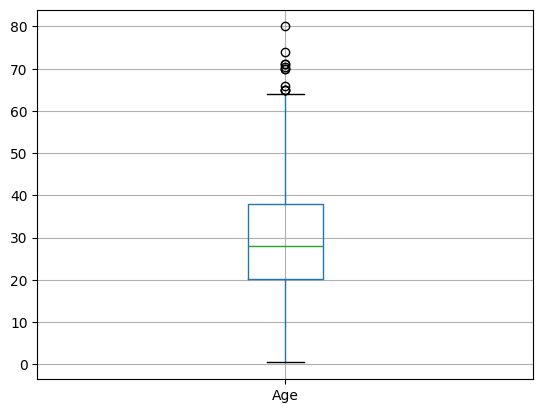

In [35]:
df.boxplot(column='Age')
plt.show()

4.3 Mengisi Nilai Kosong pada Kolom Age dengan Median

In [36]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_6696\1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


4.4 Mengisi Nilai Kosong pada Kolom Embarked dengan Modus

In [37]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_6696\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


4.5 Verifikasi Ulang Missing Values

In [38]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

### 5. Encoding Data Kategorikal

In [39]:
replacement = {
    'Sex': {'male' : 0, 'female' : 1},
    'Embarked': {'S' : 0, 'C' : 1, 'Q' : 2}
}

df.replace(replacement, inplace=True)
df.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_6696\786361704.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(replacement, inplace=True)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


### 6. Split Data dan Transformasi (Scaling)

In [40]:
# ***Split Data Variabel X dan Y***
X = df.drop('Survived' , axis=1)
Y = df['Survived']

# Tranform Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

### 7. Modeling- Menentukan Struktur Input untuk Neural Network

In [41]:
X_train.shape

(712, 8)

In [42]:
X_train.shape[1]

8

### 8. Pembuatan Model Neural Network (Arsitektur ANN)

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model  = Sequential()

# hidden layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Dropout Untuk Mengurangi Overfitting
model.add(Dropout(0.3))

# hidden layer 2
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

# output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 9. Kompilasi Model dan Ringkasan Arsitektur (Model Summary)

In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

### 10. Early Stopping (Pencegahan Overfitting Selama Training)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

### 11. Training Model Neural Network

In [46]:
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5940 - loss: 0.6673 - val_accuracy: 0.7413 - val_loss: 0.5986
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6960 - loss: 0.6119 - val_accuracy: 0.7832 - val_loss: 0.5462
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7399 - loss: 0.5608 - val_accuracy: 0.8042 - val_loss: 0.5015
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7487 - loss: 0.5306 - val_accuracy: 0.8042 - val_loss: 0.4668
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7540 - loss: 0.5241 - val_accuracy: 0.8182 - val_loss: 0.4435
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7522 - loss: 0.5137 - val_accuracy: 0.8182 - val_loss: 0.4289
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7610 - loss: 0.5138 - val_accuracy: 0.8322 - val_loss: 0.4181
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7715 - loss: 0.4757 - val_accuracy: 0.

### 12. Evaluasi Model (testing data)

In [47]:
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss     :", loss)
print("Test Accuracy :", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8045 - loss: 0.4380
Test Loss     : 0.43795594573020935
Test Accuracy : 0.8044692873954773


### 13. Visualisasi Hasil Pelatihan (Accuracy dan Loss) 

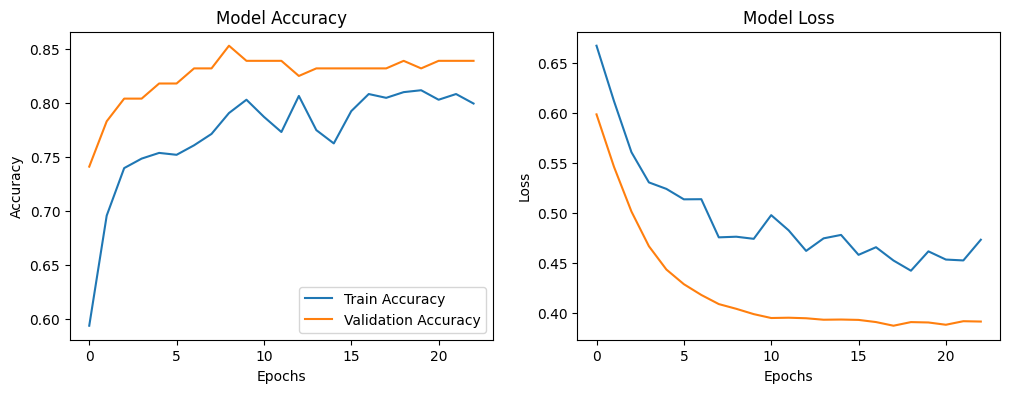

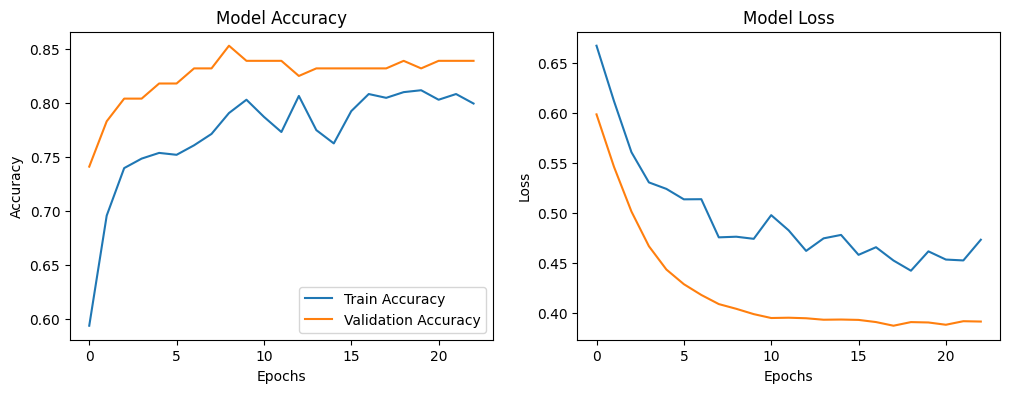

In [49]:
plt.figure(figsize=(12,4))

# acuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()